In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv(r'D:\Projects\DataScience\Emotion Detector\emotions.csv')
df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [4]:
df.info()
df['label'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    416809 non-null  str  
 1   label   416809 non-null  int64
dtypes: int64(1), str(1)
memory usage: 6.4 MB


label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

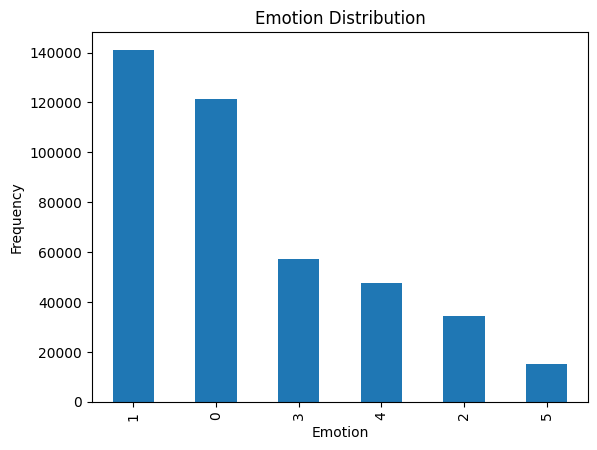

In [5]:
plt.figure()
df['label'].value_counts().plot(kind='bar')
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.show()

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

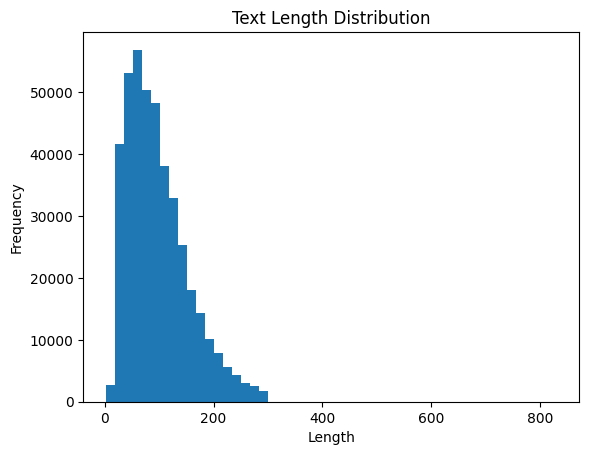

In [7]:
df['length'] = df['clean_text'].apply(len)

plt.figure()
plt.hist(df['length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [8]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)


In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9017897843141959
Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     24201
           1       0.92      0.93      0.93     28164
           2       0.81      0.77      0.79      6929
           3       0.90      0.91      0.91     11441
           4       0.86      0.85      0.85      9594
           5       0.78      0.71      0.74      3033

    accuracy                           0.90     83362
   macro avg       0.87      0.85      0.86     83362
weighted avg       0.90      0.90      0.90     83362



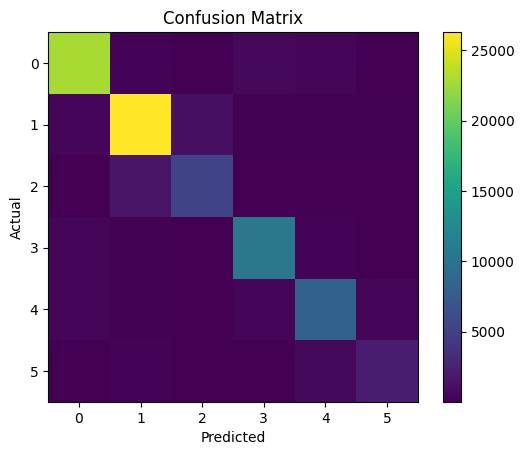

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [22]:
def predict_emotion(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    mapping = {
        0: "Sadness",
        1: "Joy",
        2: "Love",
        3: "Anger",
        4: "Fear",
        5: "Surprise"
    }
    return mapping[prediction]

In [23]:
user_text = input("Enter text: ")
print("\nInput:", user_text)
print("Emotion:", predict_emotion(user_text))


Input: I am scared about what will happen
Emotion: Fear
